<a href="https://colab.research.google.com/github/haroldchukwurah16-blip/ai-image-classifier/blob/main/AI_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [55]:
# Load the Fashion MNIST dataset

fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)

print("Testing images:", test_images.shape)
print("Testing labels:", test_labels.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


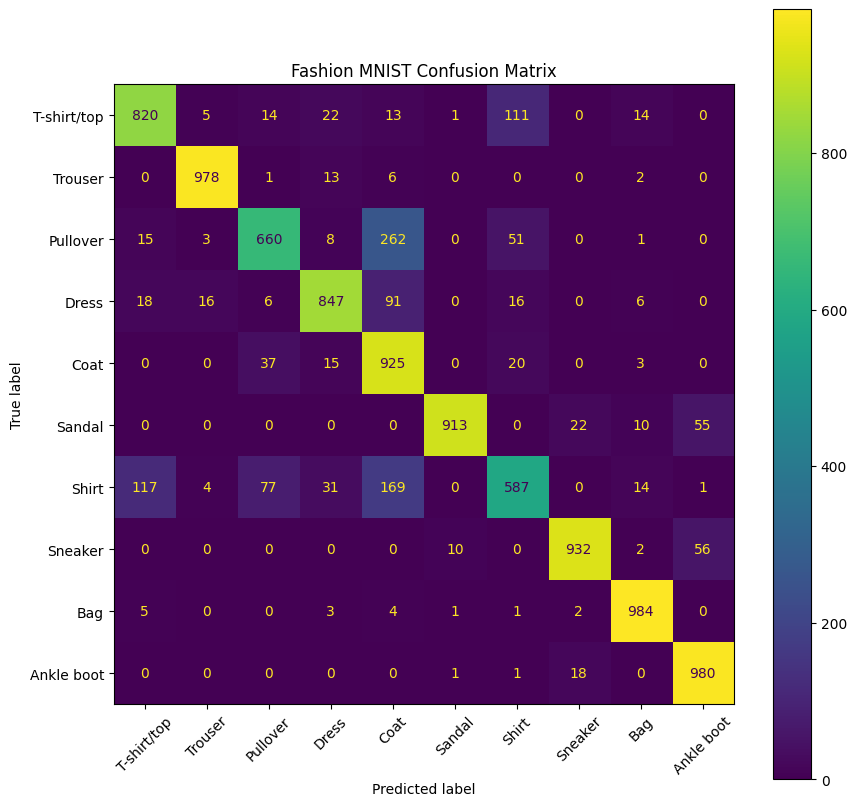

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_labels, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Fashion MNIST Confusion Matrix")
plt.show()

In [56]:
print("Confusion Matrix:")
print(cm)

mistakes = []

for actual in range(len(class_names)):
    for predicted in range(len(class_names)):
        if actual != predicted:
            mistakes.append(
                (cm[actual, predicted],
                 class_names[actual],
                 class_names[predicted])
            )

mistakes.sort(reverse=True)

print("\nMost common mistakes:")

for count, actual, predicted in mistakes[:10]:
    print(f"{actual} → {predicted}: {count}")

Confusion Matrix:
[[820   5  14  22  13   1 111   0  14   0]
 [  0 978   1  13   6   0   0   0   2   0]
 [ 15   3 660   8 262   0  51   0   1   0]
 [ 18  16   6 847  91   0  16   0   6   0]
 [  0   0  37  15 925   0  20   0   3   0]
 [  0   0   0   0   0 913   0  22  10  55]
 [117   4  77  31 169   0 587   0  14   1]
 [  0   0   0   0   0  10   0 932   2  56]
 [  5   0   0   3   4   1   1   2 984   0]
 [  0   0   0   0   0   1   1  18   0 980]]

Most common mistakes:
Pullover → Coat: 262
Shirt → Coat: 169
Shirt → T-shirt/top: 117
T-shirt/top → Shirt: 111
Dress → Coat: 91
Shirt → Pullover: 77
Sneaker → Ankle boot: 56
Sandal → Ankle boot: 55
Pullover → Shirt: 51
Coat → Pullover: 37


## Model Analysis

After evaluating the model, I used a confusion matrix to understand which classes were most difficult to distinguish.

The most common errors occurred between visually similar categories such as pullovers, coats, shirts and T-shirts. For example, the model frequently classified pullovers as coats and shirts as either coats or T-shirts.

This showed that overall accuracy alone does not explain where a model performs well or poorly, and error analysis can help identify areas for future improvement.

In [43]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

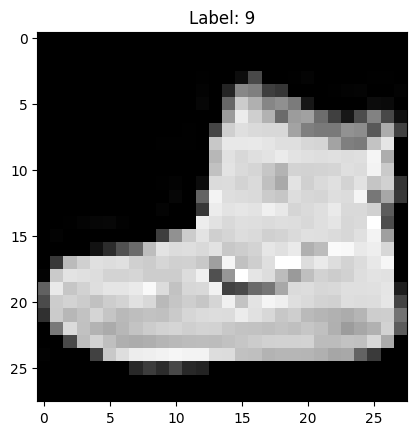

In [44]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0], cmap="gray")
plt.title(f"Label: {train_labels[0]}")
plt.show()

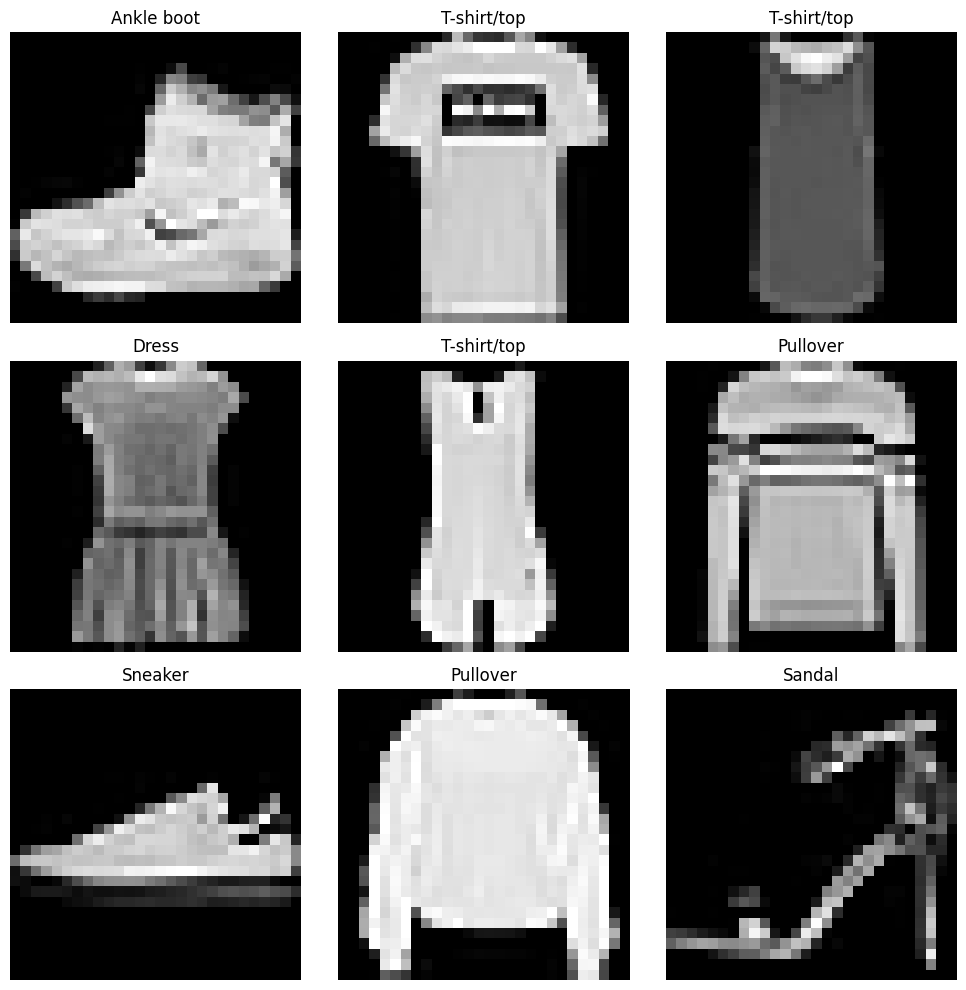

In [45]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(class_names[train_labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Training data range:", train_images.min(), "to", train_images.max())
print("Testing data range:", test_images.min(), "to", test_images.max())

Training data range: 0.0 to 1.0
Testing data range: 0.0 to 1.0


In [58]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [48]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8231 - loss: 0.5023
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8633 - loss: 0.3779
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8766 - loss: 0.3393
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8836 - loss: 0.3156
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8908 - loss: 0.2953
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8970 - loss: 0.2807
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9000 - loss: 0.2682
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9050 - loss: 0.2570
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9075 - loss: 0.2477
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9112 - loss: 0.2391


In [49]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8775 - loss: 0.3433
Test accuracy: 0.8774999976158142
Test loss: 0.34329351782798767


In [50]:
import numpy as np

predictions = model.predict(test_images)

predicted_label = np.argmax(predictions[0])
actual_label = test_labels[0]

print("Predicted:", class_names[predicted_label])
print("Actual:", class_names[actual_label])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: Ankle boot
Actual: Ankle boot


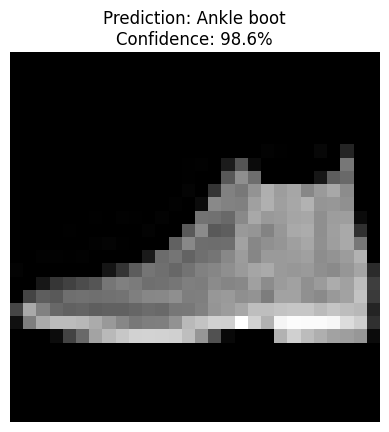

Actual: Ankle boot


In [51]:
confidence = predictions[0][predicted_label] * 100

plt.imshow(test_images[0], cmap="gray")
plt.title(
    f"Prediction: {class_names[predicted_label]}\n"
    f"Confidence: {confidence:.1f}%"
)
plt.axis("off")
plt.show()

print("Actual:", class_names[actual_label])

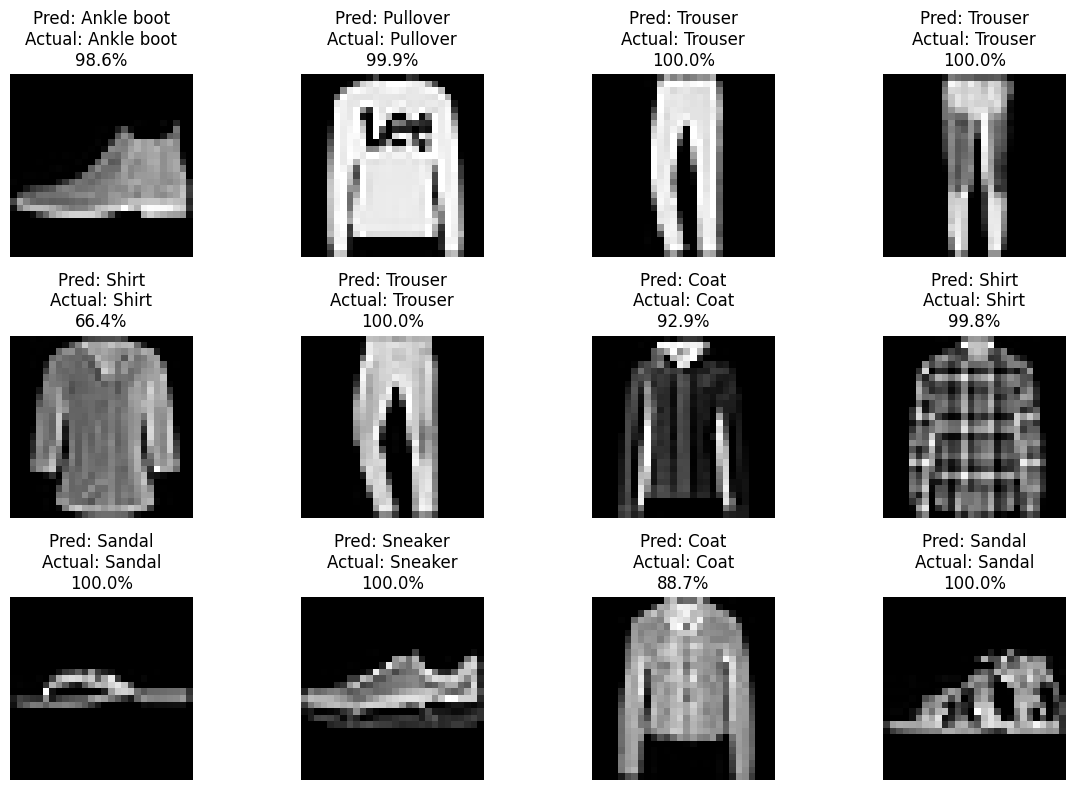

In [52]:
plt.figure(figsize=(12, 8))

for i in range(12):
    predicted_label = np.argmax(predictions[i])
    actual_label = test_labels[i]
    confidence = predictions[i][predicted_label] * 100

    plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[i], cmap="gray")

    plt.title(
        f"Pred: {class_names[predicted_label]}\n"
        f"Actual: {class_names[actual_label]}\n"
        f"{confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [53]:
model.save("fashion_mnist_model.keras")

print("Model saved successfully")

Model saved successfully
